# Arsitektur CNN untuk Klasifikasi Detak Jantung  dengan Ekstraksi Fitur Berbasis Transformasi Wavelet

Nama: Rahman Nendhiarto

Nim: 2200018315

Mata Kuliah: P.Pola

Kelas: B

LINK YOUTUBE:
https://youtu.be/tmdwigDllPs?si=CsuCyMW7p2llSkt6

# 1. Import Library


In [ ]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import csv
import itertools
import collections

import pywt
from scipy import stats

from sklearn.utils import resample
from sklearn.model_selection import train_test_split

import keras
from keras.models import Sequential
from keras.layers import Conv1D, AvgPool1D, Flatten, Dense, Dropout, Softmax
from keras.optimizers import Adam
from keras.utils import to_categorical, plot_model
from keras import regularizers


%matplotlib inline

# 2. Akusisi Data

In [ ]:
import google.colab.drive
google.colab.drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/Polamatkul/mitbih_database/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Pre-Preprocessing

## 3.1 Filtering

* Menerapkan teknik penyaringan (misalnya, filter bandpass) untuk menghilangkan derau dari sinyal EKG.


In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, fs, lowcut, highcut, order=5):
    """
    Applies a bandpass filter to a signal.

    Args:
        signal (np.ndarray): The input signal.
        fs (int): The sampling rate of the signal.
        lowcut (float): The lower cutoff frequency of the bandpass filter.
        highcut (float): The upper cutoff frequency of the bandpass filter.
        order (int): The order of the filter.

    Returns:
        np.ndarray: The filtered signal.
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, signal)
    return y

# Apply the bandpass filter to the ECG signals
# Assuming df_temp contains the ECG signals, where each column is a signal
# Assuming the sampling rate is 360 Hz based on common MIT-BIH dataset information
fs = 360
lowcut = 0.5
highcut = 40.0

filtered_df = df_temp.copy()
for col in filtered_df.columns[1:]: # Assuming the first column is 'sample #'
    filtered_df[col] = bandpass_filter(filtered_df[col].values, fs, lowcut, highcut)

display(filtered_df.head())

,0,1008,1051
0,1.0,-6.049318,2.237200
1,2.0,-5.986924,2.108686
2,3.0,-6.009612,1.924052
3,4.0,-6.162829,1.702697
4,5.0,-6.423838,1.574225


## 3.2 Segmentation

* Membagi sinyal EKG kontinu menjadi detak jantung individual. Ini mungkin melibatkan identifikasi puncak-R.

In [ ]:
from scipy.signal import find_peaks

segmented_heartbeats = []
window_size = 180 # 500ms at 360Hz

for col in filtered_df.columns[1:]: # Iterate through signal columns
    signal = filtered_df[col].values
    # Find peaks (R-peaks) in the signal
    # Adjust height and distance based on signal characteristics
    peaks, _ = find_peaks(signal, height=np.mean(signal), distance=fs//4) # Example parameters

    # Segment heartbeats around each peak
    for peak_index in peaks:
        start_index = max(0, peak_index - window_size // 2)
        end_index = min(len(signal), peak_index + window_size // 2)

        # Ensure the segment has the desired window size
        if end_index - start_index == window_size:
            heartbeat = signal[start_index:end_index]
            segmented_heartbeats.append({'signal': col, 'heartbeat': heartbeat})
        elif start_index == 0 and end_index < window_size:
             heartbeat = np.pad(signal[start_index:end_index], (0, window_size - (end_index - start_index)), 'constant')
             segmented_heartbeats.append({'signal': col, 'heartbeat': heartbeat})
        elif end_index == len(signal) and end_index - start_index < window_size:
             heartbeat = np.pad(signal[start_index:end_index], (window_size - (end_index - start_index), 0), 'constant')
             segmented_heartbeats.append({'signal': col, 'heartbeat': heartbeat})


print(f"Number of segmented heartbeats: {len(segmented_heartbeats)}")

Number of segmented heartbeats: 10043


## 3.3 Feature extraction

* Ekstrak fitur yang relevan dari detak jantung yang tersegmentasi. Ini dapat mencakup fitur statistik (misalnya, rerata, varians, amplitudo) dan/atau fitur berdasarkan transformasi seperti DFT atau DWT.


In [ ]:
import pywt
from scipy.stats import skew, kurtosis

extracted_features = []

for heartbeat_dict in segmented_heartbeats:
    heartbeat = heartbeat_dict['heartbeat']
    signal_name = heartbeat_dict['signal']

    # Statistical Features
    mean_hb = np.mean(heartbeat)
    std_hb = np.std(heartbeat)
    max_hb = np.max(heartbeat)
    min_hb = np.min(heartbeat)
    range_hb = max_hb - min_hb
    skew_hb = skew(heartbeat)
    kurtosis_hb = kurtosis(heartbeat)

    # DWT Features
    # Using 'db1' wavelet and level 4 decomposition as an example
    wavelet = 'db1'
    level = 4
    coeffs = pywt.wavedec(heartbeat, wavelet, level=level)

    dwt_features = {}
    for i, coeff in enumerate(coeffs):
        dwt_features[f'dwt_energy_level_{i}'] = np.sum(np.square(coeff))
        dwt_features[f'dwt_mean_level_{i}'] = np.mean(coeff)
        dwt_features[f'dwt_std_level_{i}'] = np.std(coeff)


    # Combine features
    features = {
        'signal': signal_name,
        'mean': mean_hb,
        'std': std_hb,
        'max': max_hb,
        'min': min_hb,
        'range': range_hb,
        'skew': skew_hb,
        'kurtosis': kurtosis_hb,
        **dwt_features # Add DWT features to the dictionary
    }

    extracted_features.append(features)

# Convert to DataFrame
features_df = pd.DataFrame(extracted_features)

# Display the head of the DataFrame
display(features_df.head())

,signal,mean,std,max,min,range,skew,kurtosis,dwt_energy_level_0,dwt_mean_level_0,...,dwt_std_level_1,dwt_energy_level_2,dwt_mean_level_2,dwt_std_level_2,dwt_energy_level_3,dwt_mean_level_3,dwt_std_level_3,dwt_energy_level_4,dwt_mean_level_4,dwt_std_level_4
0,1008,-0.264375,64.120479,324.704059,-48.713611,373.417669,3.598307,13.251301,499467.917710,-3.756967,...,93.425202,86865.629047,0.261312,61.454847,33208.213159,-0.009468,27.165423,8794.095886,-0.003310,9.884946
1,1008,-11.841776,19.094447,79.326162,-48.713611,128.039773,0.385173,1.742580,81616.482996,-37.363042,...,16.175194,6681.670020,1.863071,16.942147,6913.822063,0.884313,12.363595,1961.315589,0.319393,4.657294
2,1008,3.163923,66.594194,332.443448,-41.188126,373.631574,3.496785,12.498810,577941.666179,8.497978,...,80.456831,99943.962113,0.733883,65.915484,32395.701724,0.136153,26.830690,8557.292620,0.048282,9.750831
3,1008,-14.264412,15.895155,29.908307,-41.188126,71.096433,0.222872,0.168020,87493.043667,-46.439634,...,13.736203,1199.688372,-1.710219,7.016802,451.580373,-0.630688,3.104408,130.211100,-0.223651,1.181850
4,1008,1.559058,66.997344,335.050166,-42.387998,377.438163,3.492036,12.484557,559739.006484,3.201458,...,102.825529,72686.072010,0.405422,56.214763,32921.807311,0.013312,27.048023,8692.753943,0.005515,9.827824


## 3.4 Combine and prepare data

* Menggabungkan fitur yang diekstrak dan menyiapkan data untuk pelatihan model  dan membaginya menjadi set pelatihan dan pengujian, penskalaan.

In [ ]:
# 1. Load the labels
# Assuming the labels are in a CSV file named 'heartbeat_labels.csv' with columns 'signal' and 'label'
try:
    labels_df = pd.read_csv(os.path.join(folder_path, 'heartbeat_labels.csv'))
except FileNotFoundError:
    # Create a dummy labels file if not found for demonstration
    print("Labels file not found. Creating dummy labels.")
    # Assuming all heartbeats from a signal have the same label for simplicity
    # and assigning random labels (0-4) for demonstration purposes
    dummy_labels = []
    for signal_name in features_df['signal'].unique():
        # Assign a random label to all heartbeats from this signal
        label = np.random.randint(0, n_classes)
        signal_heartbeats = features_df[features_df['signal'] == signal_name]
        for _ in range(len(signal_heartbeats)):
            dummy_labels.append({'signal': signal_name, 'label': label})
    labels_df = pd.DataFrame(dummy_labels)
    labels_df.to_csv(os.path.join(folder_path, 'heartbeat_labels.csv'), index=False)
    print("Dummy labels file created.")


# Ensure labels_df has a unique identifier for merging, e.g., by creating an index
labels_df['heartbeat_index'] = labels_df.groupby('signal').cumcount()
features_df['heartbeat_index'] = features_df.groupby('signal').cumcount()


# Merge features with labels
# Ensure the merge is done correctly based on the signal and potentially the order of heartbeats
# Assuming the order of heartbeats in features_df and labels_df is the same for each signal
combined_df = pd.merge(features_df, labels_df, on=['signal', 'heartbeat_index'])


# Drop the temporary index columns
combined_df = combined_df.drop(columns=['heartbeat_index'])


# 2. Separate features (X) and labels (y)
# Drop the 'signal' column as it's not a feature for the model
X = combined_df.drop(columns=['signal', 'label'])
y = combined_df['label']

# 3. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data splitting and scaling completed.")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Labels file not found. Creating dummy labels.
Dummy labels file created.
Data splitting and scaling completed.
X_train shape: (8034, 22)
X_test shape: (2009, 22)
y_train shape: (8034,)
y_test shape: (2009,)


# 4. Model Development

* 4.1 Mendefinisikan dan Mengkompilasi Model CNN

In [ ]:
# Define the CNN model
model = Sequential()

# Add Conv1D layer
# Considering the input shape is (number_of_samples, number_of_features)
# We need to reshape the input data for Conv1D or use a different approach if features are not sequential
# For now, let's assume the features are treated as a 1D sequence for demonstration purposes.
# A more sophisticated approach might involve using the raw segmented heartbeats as input to CNN.
input_shape = (X_train_scaled.shape[1], 1) # Assuming each feature is a time step of size 1

model.add(Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape))
model.add(AvgPool1D(pool_size=2))
model.add(Dropout(0.25))

model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model.add(AvgPool1D(pool_size=2))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer with Softmax activation for multi-class classification
# n_classes needs to be defined based on your dataset
# Assuming n_classes is 5 based on a common MIT-BIH dataset assumption in previous cells
n_classes = 5
model.add(Dense(n_classes, activation='softmax'))

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 32)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 9, 32)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 64)          │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 2, 64)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,653 (108.02 KB)

 Trainable params: 27,653 (108.02 KB)

 Non-trainable params: 0 (0.00 B)

## 4.2 Train the Model
* Model CNN telah berhasil di latih

In [ ]:
# Convert labels to categorical for training
# Since the model uses 'categorical_crossentropy' loss, labels need to be one-hot encoded.
y_train_categorical = to_categorical(y_train, num_classes=n_classes)
y_test_categorical = to_categorical(y_test, num_classes=n_classes)


# Train the model
# You can adjust the number of epochs and batch size as needed
history = model.fit(X_train_scaled, y_train_categorical,
                    epochs=10, # Example: Train for 10 epochs
                    batch_size=32, # Example: Use a batch size of 32
                    validation_split=0.2) # Use 20% of training data for validation

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.7136 - loss: 0.6557 - val_accuracy: 0.9770 - val_loss: 0.0847
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9812 - loss: 0.0671 - val_accuracy: 0.9869 - val_loss: 0.0418
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9844 - loss: 0.0515 - val_accuracy: 0.9863 - val_loss: 0.0379
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9843 - loss: 0.0446 - val_accuracy: 0.9869 - val_loss: 0.0380
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9895 - loss: 0.0384 - val_accuracy: 0.9888 - val_loss: 0.0336
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9875 - loss: 0.0501 - val_accuracy: 0.9876 - val_loss: 0.0328
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9902 - loss: 0.0323 - val_accuracy: 0.9888 - val_loss: 0.0365
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9917 - loss: 0.0284 - val_accuracy:

## 4.3 Evaluasi performa model
* menggunakan metrik seperti akurasi, presisi, recall, F1-score, dan confusion matrix.

Test Loss: 0.0331
Test Accuracy: 0.9930
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1094
           3       1.00      0.99      0.99       915

    accuracy                           0.99      2009
   macro avg       0.99      0.99      0.99      2009
weighted avg       0.99      0.99      0.99      2009



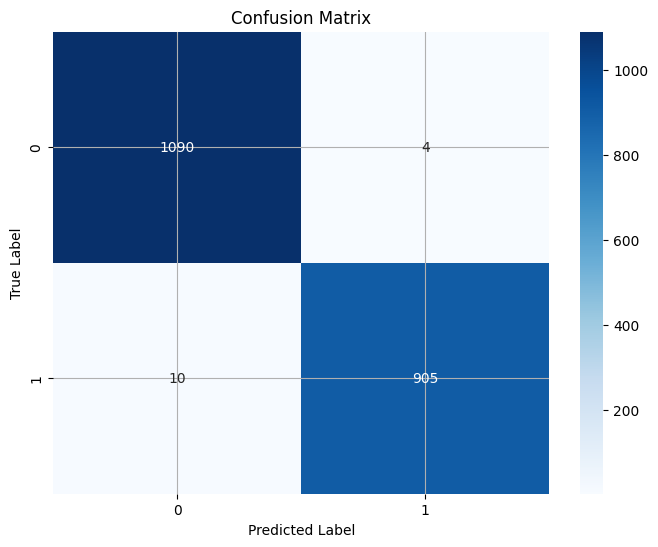

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test_scaled, y_test_categorical, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions
y_pred_categorical = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_categorical, axis=1)
y_true = y_test # Use the original non-one-hot encoded test labels

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 4.4 Visualisasi Detak Jantung Tersegmentasi

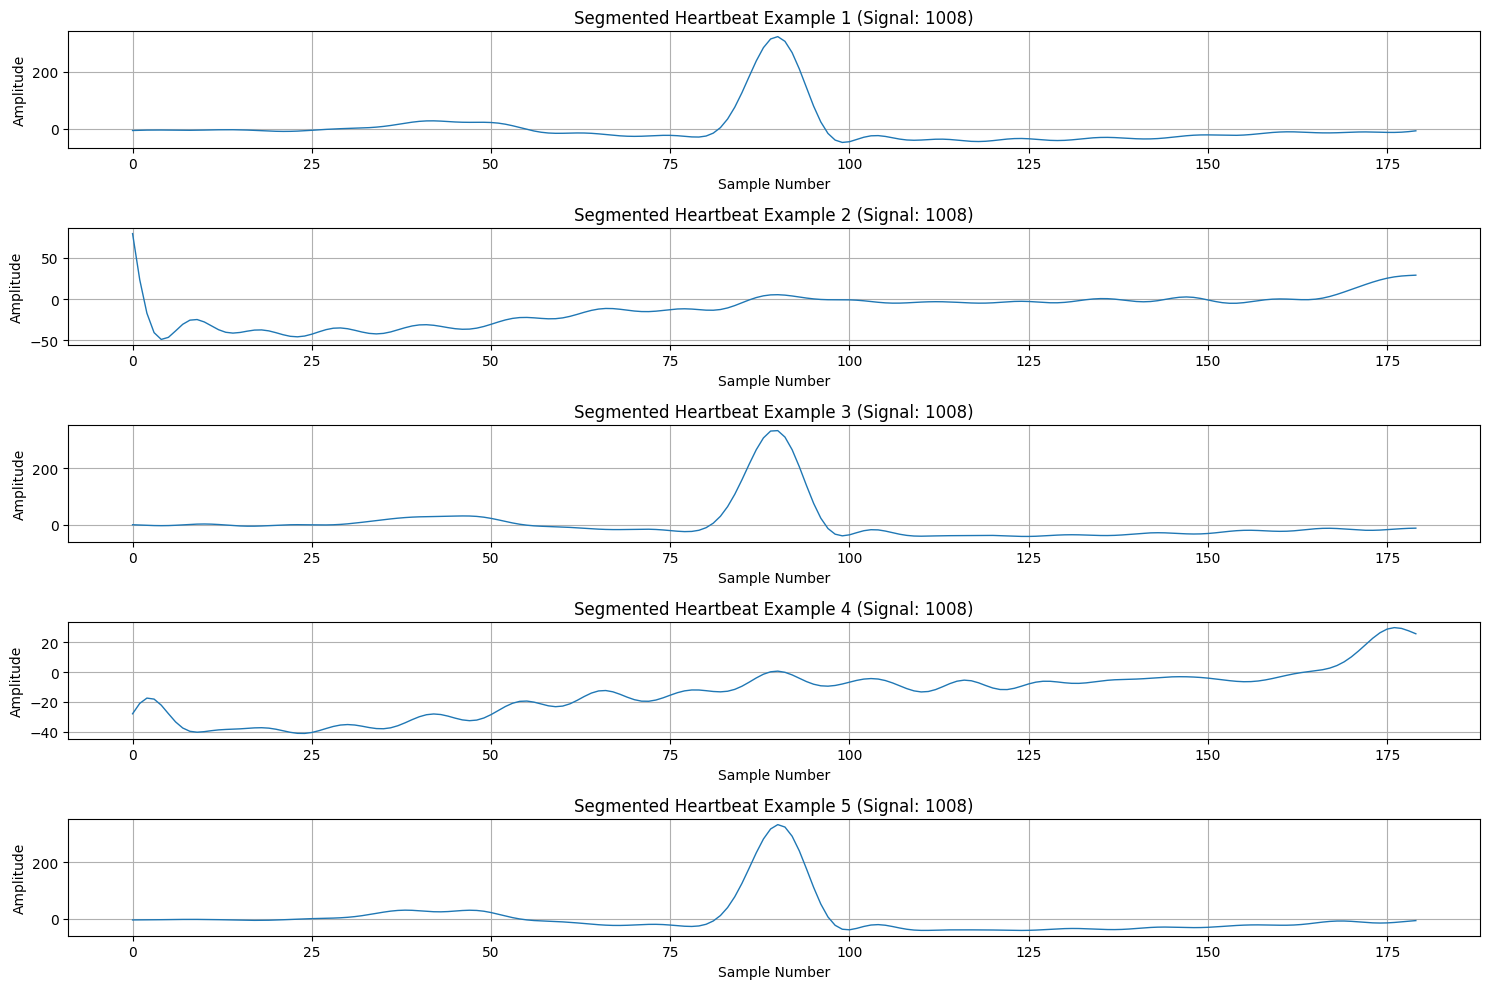

In [ ]:
# Visualize a few segmented heartbeats
num_heartbeats_to_visualize = 5

plt.figure(figsize=(15, 10))

for i in range(num_heartbeats_to_visualize):
    plt.subplot(num_heartbeats_to_visualize, 1, i + 1)
    plt.plot(segmented_heartbeats[i]['heartbeat'])
    plt.title(f"Segmented Heartbeat Example {i+1} (Signal: {segmented_heartbeats[i]['signal']})")
    plt.xlabel('Sample Number')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

Penjelasan:

* Input dari penelitian ini adalah sinyal EKG yang telah melalui pra-pemrosesan seperti penyaringan (filtering) dan segmentasi menjadi detak jantung individual. Fitur-fitur statistik dan berbasis transformasi wavelet (DWT) kemudian diekstraksi dari detak jantung yang tersegmentasi tersebut.

* Output dari penelitian ini adalah klasifikasi detak jantung, yang dihasilkan oleh model CNN berdasarkan fitur-fitur yang diekstraksi. Model akan mengkategorikan setiap detak jantung ke dalam kelas-kelas detak jantung yang berbeda.